# TASK - 1

In [ ]:
!pip install ultralytics roboflow

from google.colab import drive
from roboflow import Roboflow
from ultralytics import YOLO

drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 95.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="QuXkqRe1d5MEciQKnwPI")
project = rf.workspace("prueba1-jkmge").project("cars-cars-cars")
version = project.version(2)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cars-cars-cars-2 in yolov8:: 100%|██████████| 3542/3542 [00:01<00:00, 3391.68it/s]


Running prediction on: /content/Test Car.jpg (3).jpg

image 1/1 /content/Test Car.jpg (3).jpg: 640x320 5 3s, 750.1ms
Speed: 12.5ms preprocess, 750.1ms inference, 76.8ms postprocess per image at shape (1, 3, 640, 320)
Results saved to /content/runs/detect/predict
Displaying saved image from: runs/detect/predict/Test Car.jpg (3).jpg


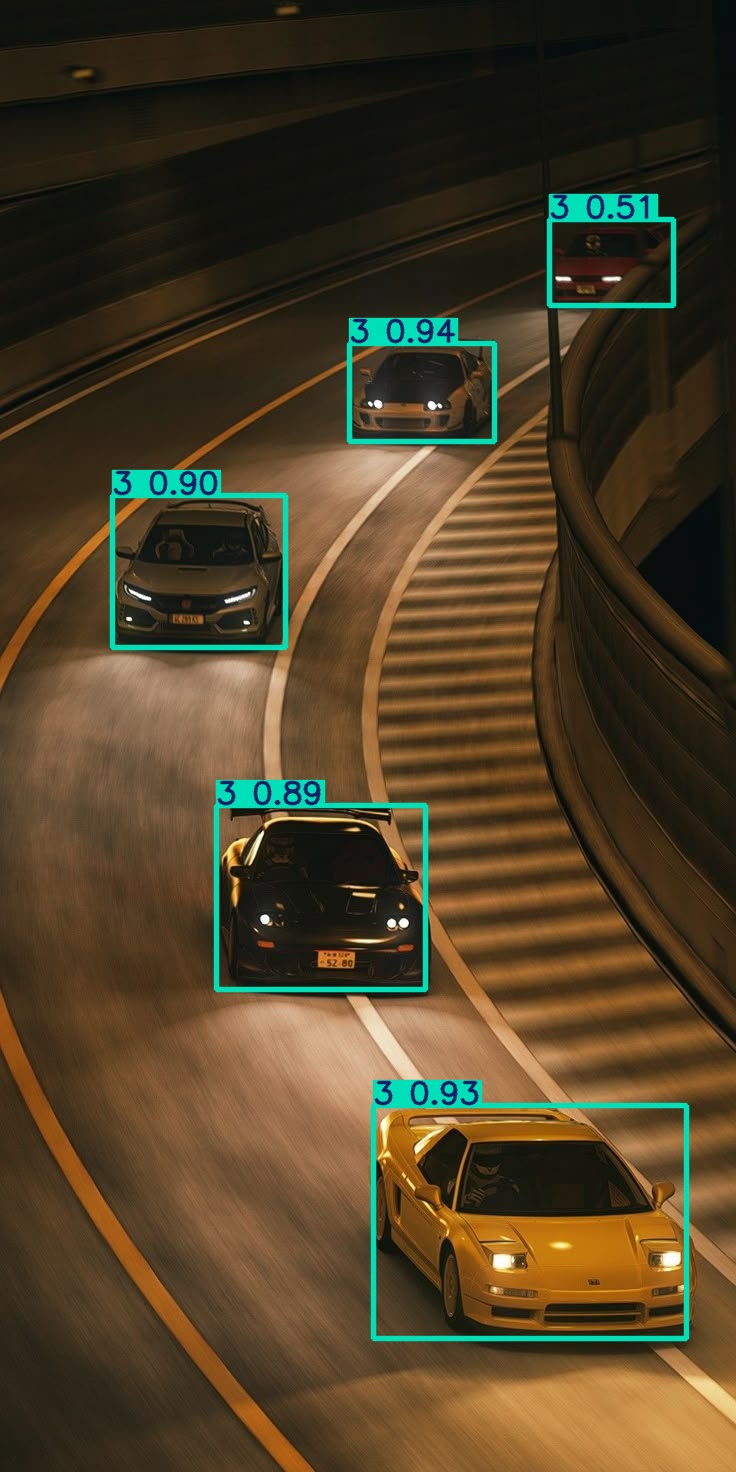

In [ ]:
from IPython.display import Image, display
import os
file_path = "/content/Test Car.jpg (3).jpg"
file_name = os.path.basename(file_path)
model_path = '/content/drive/MyDrive/My_YOLOv8_Projects/Road_Traffic_Detection/weights/best.pt'
model = YOLO(model_path)
print(f"Running prediction on: {file_path}")
results = model.predict(file_path, save=True)
output_path = f'runs/detect/predict/{file_name}'
print(f"Displaying saved image from: {output_path}")

display(Image(filename=output_path))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### TASK-2

In [ ]:

!pip install -q ultralytics
!apt-get -qq install ffmpeg

import os
import glob
from google.colab import drive
from ultralytics import YOLO
from IPython.display import Video, display


try:
    drive.mount('/content/drive')
except:
    print("Drive already mounted or error mounting.")


input_video_path = "/content/drive/MyDrive/trafficvideo (3).mp4"




resized_video_path = "resized_video_for_yolo.mp4"

temp_project_folder = "runs/detect"
temp_run_name = "video_output"

output_folder = f"{temp_project_folder}/{temp_run_name}"

print("--- Paths Defined ---")
print(f"Input: {input_video_path}")
print(f"Output will be in: {output_folder}")
print("-" * 20)

if not os.path.exists(input_video_path):
    print(f"Error: Input video not found at: {input_video_path}")
    print("Please fix the path in STEP 2 and re-run.")
else:
    print("Input video found. Resizing for faster processing...")

    !ffmpeg -i "{input_video_path}" -vf scale=640:360 "{resized_video_path}" -y -loglevel quiet
    print("Video resizing complete.")
    print("-" * 20)


if os.path.exists(resized_video_path):
    print("Running YOLO detection on the video...")
    !yolo predict model=yolov8n.pt source="{resized_video_path}" project="{temp_project_folder}" name="{temp_run_name}"
    print("YOLO processing complete.")
    print("-" * 20)
else:
    print("Skipping YOLO run because resized video was not created.")



print(f"Looking for output video in: {output_folder}")


video_files = glob.glob(f"{output_folder}/*.avi") + glob.glob(f"{output_folder}/*.mp4")

if video_files:
    original_output_path = video_files[0]
    final_mp4_path = os.path.join(output_folder, "final_video_output.mp4")

    print(f"Found output: {original_output_path}")
    print(f"Converting to {final_mp4_path} for display...")


    !ffmpeg -i "{original_output_path}" -c:v libx264 -pix_fmt yuv420p "{final_mp4_path}" -y -loglevel quiet

    print("Conversion complete. Displaying video:")

    display(Video(final_mp4_path, embed=True, width=840))

else:
    print(f"Error: No output video file was found in {output_folder}")
    print("Check if the YOLO run (STEP 4) completed successfully.")
    print("-" * 20)

### **TASK-3**

In [ ]:
# Install Roboflow
!pip install -q roboflow

from roboflow import Roboflow
from google.colab import drive
import os
import shutil

drive.mount('/content/drive')

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="QuXkqRe1d5MEciQKnwPI")
project = rf.workspace("ideal-institute-of-tehnology").project("milestone1-ofhcq")
version = project.version(1)
dataset = version.download("yolov8")


dataset = version.download("yolov8")

drive_output_path = "/content/drive/MyDrive/AI-Powered Assistive Mobility Tool for Visually Impaired/Merged_Traffic_Dataset_YOLOv8"
os.makedirs(drive_output_path, exist_ok=True)


target_path = os.path.join(drive_output_path, os.path.basename(dataset.location))

if os.path.exists(target_path):
    print(f"Dataset already exists in Google Drive at: {target_path}. Skipping move...")
else:

    shutil.move(dataset.location, drive_output_path)
    print(f"Dataset successfully saved to Google Drive at: {target_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 23.7 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to MileStone1-1 in yolov8:: 100%|██████████| 1568/1568 [00:00<00:00, 5675.90it/s]


Dataset already exists in Google Drive at: /content/drive/MyDrive/AI-Powered Assistive Mobility Tool for Visually Impaired/Merged_Traffic_Dataset_YOLOv8/MileStone1-1. Skipping move...
